# Kwant — Theory and Practice · Chapter 4
## Local observables and visualisation

*Part I · Sections 10–11 · Figures 19–23* &nbsp;·&nbsp; [← Chapter 3](03_Graphene_and_Superconductivity.ipynb) · [Contents](00_Contents.ipynb) · [Chapter 5 →](05_KPM_and_Continuum.ipynb)

### In this chapter

- [10. Local observables — density and current operators](#10.-Local-observables-—-density-and-current-operators)
    - [Density](#Density)
    - [Current](#Current)
    - [Usage](#Usage)
- [11. Visualisation](#11.-Visualisation)

Run the **Setup** cell first: it imports Kwant, reports the sparse solver, mutes three library warnings and defines `show_fig`, whose figure counter continues the course-wide numbering. Each chapter is self-contained given its Setup cell (a *carried over* cell, where present, rebuilds an object defined in an earlier chapter). Installation, the `kwant` kernel and the conventions are in [`00_Contents.ipynb`](00_Contents.ipynb).

`SPDX-License-Identifier: Apache-2.0` — Copyright 2026 Fabio Campolim.


In [1]:
# --- Setup: run this cell first ----------------------------------------------
# Imports, the sparse-solver report, three muted library warnings, and the
# figure helper.  Every chapter of the course starts with this cell.
import kwant
import numpy as np
import scipy
import tinyarray as ta                   # noqa: F401  (used by later cells)
import matplotlib
from matplotlib import pyplot

print("kwant", kwant.__version__, "| numpy", np.__version__,
      "| scipy", scipy.__version__, "| matplotlib", matplotlib.__version__)

# Which sparse solver is active? MUMPS is much faster than SciPy's SuperLU.
import kwant.solvers.default
print("default solver:", kwant.solvers.default.__name__)
try:
    import kwant.solvers.mumps          # noqa: F401
    print("MUMPS available: yes")
except ImportError:
    print("MUMPS available: no  (falling back to scipy sparse -> slower)")

matplotlib.rcParams['figure.figsize'] = (7, 5)

# Mute three library warnings that are not ours to fix and would otherwise be
# printed under some figures.  Done by wrapping warnings.showwarning rather than
# with warnings.filterwarnings(), because kwant.plotter calls
# warnings.resetwarnings() on every 3D plot, which silently deletes all user
# filters (reported upstream).  Only these three messages are muted:
#  * kwant 1.5.0's 3D plotter calls a matplotlib function deprecated in 3.10
#    (fixed on Kwant's main branch, unreleased);
#  * mpmath (via sympy) uses a deprecated bitcount helper;
#  * kwant.plotter.map notes that a few density values exceed the colour range,
#    which is expected for the delta-like densities in sections 6 and 12.
import warnings
_MUTED = ('proj_transform_clip', 'bitcount function is deprecated', 'overflowing upper limit')
_showwarning = warnings.showwarning

def _quiet_showwarning(message, category, filename, lineno, file=None, line=None):
    if not any(k in str(message) for k in _MUTED):
        _showwarning(message, category, filename, lineno, file, line)

warnings.showwarning = _quiet_showwarning

# --- Figure helper ------------------------------------------------------------
# Every figure ends with show_fig("..."), which stamps an auto-numbered italic
# caption under the figure and then shows it.  Figures are numbered
# continuously across the chapters of the course: this chapter's figures are
# 19–23, so the counter starts at 18.  (Re-running a single cell out of
# order advances it -- harmless, but numbers shift.)
_FIG_NO = [18]

def show_fig(caption=None):
    if caption:
        _FIG_NO[0] += 1
        fig = pyplot.gcf()
        fig.text(0.5, -0.02, f"Figure {_FIG_NO[0]}: {caption}",
                 ha='center', va='top', fontsize=9, style='italic',
                 wrap=True, transform=fig.transFigure)
    pyplot.show()


kwant 1.5.0 | numpy 2.5.1 | scipy 1.18.0 | matplotlib 3.10.7
default solver: kwant.solvers.default
MUMPS available: yes


In [2]:
# --- Carried over from section 6 -----------------------------------
# the Rashba + Zeeman wire `fsyst_r` of § 6 (the density and current maps are drawn on it).
# The code is the definition of section 6, verbatim.
import kwant, numpy as np, tinyarray as ta
from matplotlib import pyplot
sigma_0 = ta.array([[1, 0], [0, 1]])
sigma_x = ta.array([[0, 1], [1, 0]])
sigma_y = ta.array([[0, -1j], [1j, 0]])
sigma_z = ta.array([[1, 0], [0, -1]])
t, alpha, e_z = 1.0, 0.5, 0.08
W, L = 10, 30
lat = kwant.lattice.square(norbs=2)
def make_rashba(W=10, L=30):
    syst = kwant.Builder()
    syst[(lat(x, y) for x in range(L) for y in range(W))] = \
        4 * t * sigma_0 + e_z * sigma_z
    syst[kwant.builder.HoppingKind((1, 0), lat, lat)] = \
        -t * sigma_0 + 1j * alpha * sigma_y / 2
    syst[kwant.builder.HoppingKind((0, 1), lat, lat)] = \
        -t * sigma_0 - 1j * alpha * sigma_x / 2

    lead = kwant.Builder(kwant.TranslationalSymmetry((-1, 0)))
    lead[(lat(0, j) for j in range(W))] = 4 * t * sigma_0 + e_z * sigma_z
    lead[kwant.builder.HoppingKind((1, 0), lat, lat)] = \
        -t * sigma_0 + 1j * alpha * sigma_y / 2
    lead[kwant.builder.HoppingKind((0, 1), lat, lat)] = \
        -t * sigma_0 - 1j * alpha * sigma_x / 2

    syst.attach_lead(lead)
    syst.attach_lead(lead.reversed())
    return syst

fsyst_r = make_rashba().finalized()


---
## 10. Local observables — density and current operators

Transmission is a *global* number. To see **where** things happen you need local
quantities, and `kwant.operator` provides them with the correct lattice definitions.

### Density

For an operator $M$ acting in orbital space, the local density on site $i$ is

$$\rho_i^{M}[\psi] = \psi_i^\dagger M \psi_i .$$

With $M = \mathbb{1}$ this is the probability density; with $M = \sigma_z$ the
$z$-spin density; with $M = \tau_z$ the charge density in Nambu space.

### Current

The current is subtler: on a lattice it lives on **bonds**, not sites, and follows from the
continuity equation $\partial_t \rho + \nabla\!\cdot\! J = 0$. Kwant implements

$$J_{ij}^{M}[\psi] = i\left(\psi_i^\dagger H_{ij} M \psi_j
- \psi_j^\dagger M H_{ij}^\dagger \psi_i\right),$$

the current flowing from site $j$ to site $i$. Choosing $M$ gives charge current
($M=\mathbb{1}$), spin current ($M=\sigma_z$), etc.

> **Spin current caveat.** With spin–orbit coupling, spin is not conserved, so the "spin
> current" defined this way does not satisfy a continuity equation. It is still a
> well-defined observable — just do not over-interpret it.

### Usage

```python
rho   = kwant.operator.Density(fsyst)             # M = identity
rho_z = kwant.operator.Density(fsyst, sigma_z)
J     = kwant.operator.Current(fsyst)
J_z   = kwant.operator.Current(fsyst, sigma_z)

psi = kwant.wave_function(fsyst, energy, params=...)(0)[0]
density = rho(psi)        # one number per site
current = J(psi)          # one number per hopping
```

Operators accept `where=` to restrict evaluation to a region (e.g. a cross-section, to get
a total current through it) and `sum=True` to return the total directly. `M` may also be a
*function* of the site, for position-dependent observables such as a spin texture.

Plot with `kwant.plotter.density(...)` / `kwant.plotter.map(...)` for densities and
`kwant.plotter.current(...)` for currents — the latter does the streamline interpolation
for you.

> `norbs` **must** be set on your lattices for `kwant.operator` to work.

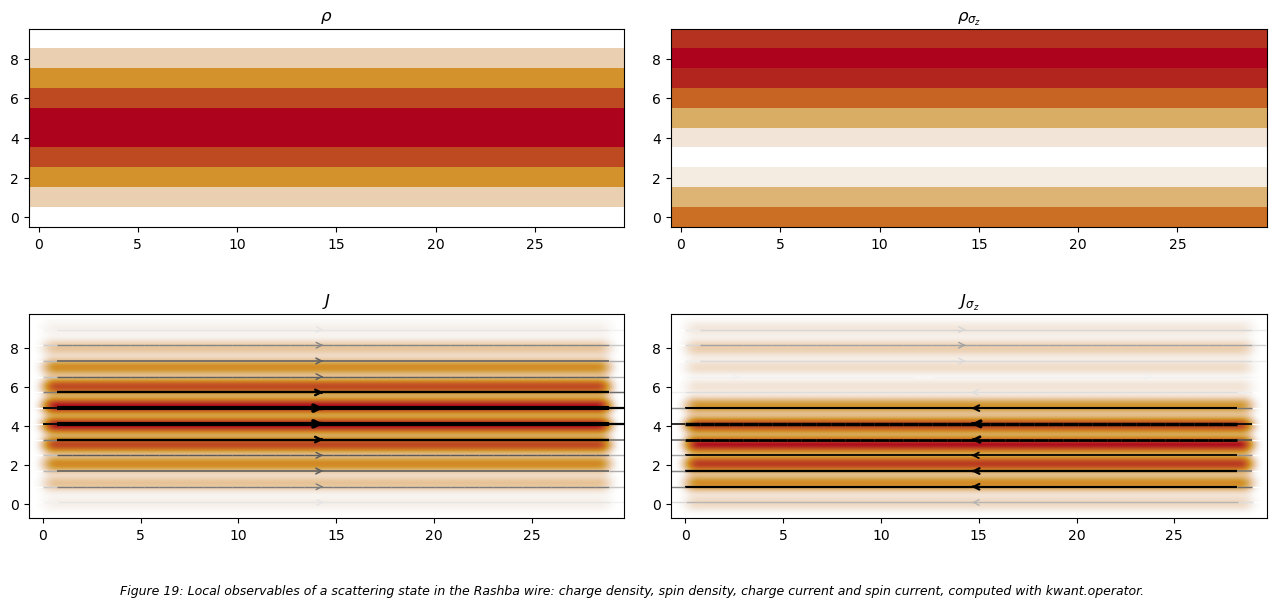

In [3]:
# --- Density and current maps in the Rashba wire -----------------------------
import kwant, numpy as np, tinyarray as ta
from matplotlib import pyplot

sigma_0 = ta.array([[1, 0], [0, 1]])
sigma_y = ta.array([[0, -1j], [1j, 0]])
sigma_z = ta.array([[1, 0], [0, -1]])

# reuse the Rashba system from section 6
psi = kwant.wave_function(fsyst_r, energy=0.4)(0)[0]

rho    = kwant.operator.Density(fsyst_r)
rho_sz = kwant.operator.Density(fsyst_r, sigma_z)
J      = kwant.operator.Current(fsyst_r)
J_sz   = kwant.operator.Current(fsyst_r, sigma_z)

density   = rho(psi)
spin_z    = rho_sz(psi)
current   = J(psi)
spin_curr = J_sz(psi)

fig, axes = pyplot.subplots(2, 2, figsize=(13, 6))
kwant.plotter.map(fsyst_r, density, ax=axes[0, 0]); axes[0, 0].set_title(r"$\rho$")
kwant.plotter.map(fsyst_r, spin_z,  ax=axes[0, 1]); axes[0, 1].set_title(r"$\rho_{\sigma_z}$")
kwant.plotter.current(fsyst_r, current,   ax=axes[1, 0], colorbar=False)
axes[1, 0].set_title(r"$J$")
kwant.plotter.current(fsyst_r, spin_curr, ax=axes[1, 1], colorbar=False)
axes[1, 1].set_title(r"$J_{\sigma_z}$")
pyplot.tight_layout(); show_fig(r'Local observables of a scattering state in the Rashba wire: charge density, spin density, charge current and spin current, computed with kwant.operator.')

In [4]:
# --- Total current through a cross-section, and current conservation ---------
# 'where' restricts the operator to a set of hoppings; 'sum' returns the total.
lat_r = kwant.lattice.square(norbs=2)

def cut(site_to, site_from):
    # hoppings crossing the plane x = 15, pointing in +x
    return site_from.pos[0] == 15 and site_to.pos[0] == 16

J_cut = kwant.operator.Current(fsyst_r, where=cut, sum=True)

wf = kwant.wave_function(fsyst_r, energy=0.4)
total = sum(J_cut(p) for p in wf(0))
print("total current through x = 15.5 :", total)

# Compare with the transmission -- they must agree (up to the flux normalisation
# Kwant uses, in which each scattering state carries unit flux).
print("transmission T(1<-0)           :", kwant.smatrix(fsyst_r, 0.4).transmission(1, 0))

total current through x = 15.5 : 4.000000000000001
transmission T(1<-0)           : 3.9999999999999973


---
## 11. Visualisation

| Function | Draws |
|---|---|
| `kwant.plot(syst)` | the lattice: sites and bonds (works on `Builder` *or* finalised) |
| `kwant.plotter.map(fsyst, values)` | a per-site scalar, interpolated onto a raster |
| `kwant.plotter.density(fsyst, values)` | a per-site scalar, smoothed (nicer for LDOS) |
| `kwant.plotter.current(fsyst, values)` | a per-hopping vector field, as streamlines |
| `kwant.plotter.bands(flead)` | lead dispersion |
| `kwant.plotter.spectrum(fsyst, (name, vals))` | eigenvalues vs a parameter |
| `kwant.plotter.sys_leads_sites` etc. | low-level helpers |

Every visual property accepts a **callable of the site (or hopping)**, which is how you
colour sublattices, size sites by wave-function weight, or vary bond thickness:

```python
kwant.plot(syst,
           site_color=lambda s: 'black' if s.family == a else 'white',
           site_size=lambda i: 3 * wf[i] / wf.max(),
           hop_lw=lambda s1, s2: 0.04 if s1.family == s2.family else 0.1)
```

Note the inconsistency to watch for: on a **`Builder`** the callbacks receive `Site`
objects; on a **finalised** system they receive integer site *indices*. 3-D systems plot
too — `kwant.plot` handles them with the same call.

Kwant 1.5 added **Plotly** as an alternative backend: `kwant.plotter.set_engine('plotly')`,
with `kwant.plotter.get_engine()` to query it. It covers every plotting function
**except streamplots** (so `plotter.current` stays on matplotlib), and gives interactive,
rotatable 3-D plots.

> Kwant's plotting fixes matplotlib's backend on first use. If you want a specific backend,
> select it *before* calling any Kwant plotting function.

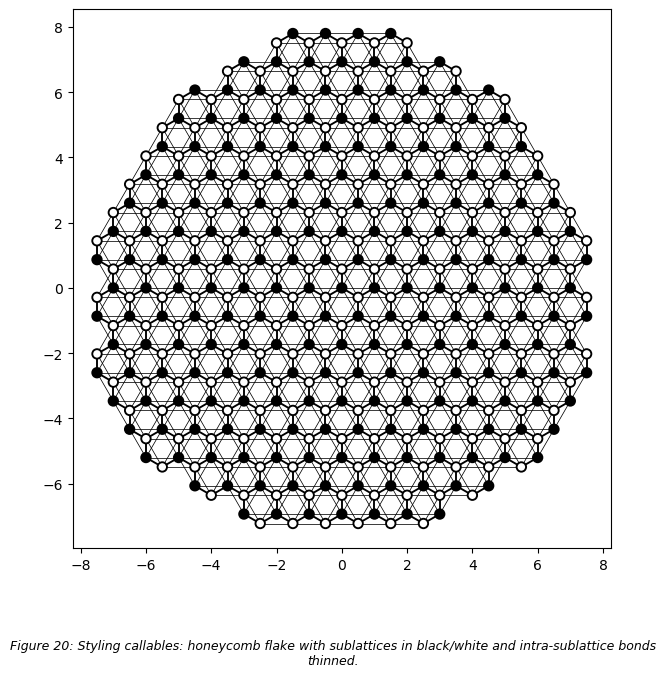

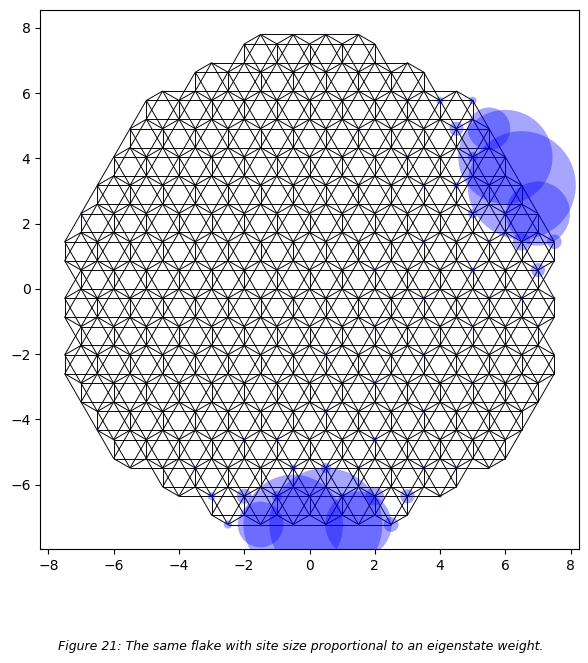

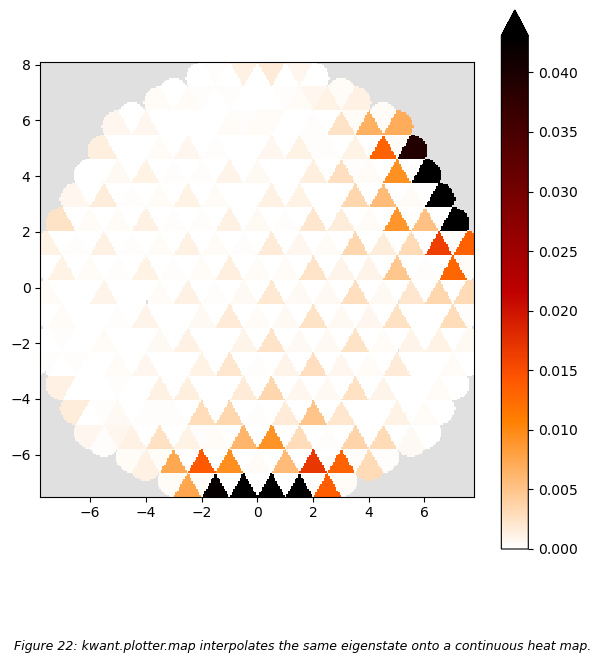

In [5]:
# --- Styling: sublattices, wave-function weight, 3D --------------------------
import kwant, numpy as np
import scipy.linalg as la
from matplotlib import pyplot

lat = kwant.lattice.honeycomb(norbs=1)
a_sub, b_sub = lat.sublattices

def circle(pos):
    x, y = pos
    return x**2 + y**2 < 8**2

flake = kwant.Builder()
flake[lat.shape(circle, (0, 0))] = 0
flake[lat.neighbors()] = -1
flake.eradicate_dangling()             # kill spurious dangling-atom states
flake[lat.neighbors(2)] = -0.1         # next-nearest neighbours

# colour by sublattice, thin the intra-sublattice bonds
kwant.plot(flake,
           site_color=lambda s: 'black' if s.family == a_sub else 'white',
           hop_lw=lambda s1, s2: 0.04 if s1.family == s2.family else 0.1,
           site_lw=0.1, fig_size=(7, 7), show=False)
show_fig(r'Styling callables: honeycomb flake with sublattices in black/white and intra-sublattice bonds thinned.')

# size the sites by an eigenstate's weight
fflake = flake.finalized()
evecs = la.eigh(fflake.hamiltonian_submatrix())[1]
wf = np.abs(evecs[:, len(evecs) // 2])**2

kwant.plot(fflake, site_size=lambda i: 3 * wf[i] / wf.max(),
           site_color=(0, 0, 1, 0.35), hop_lw=0.05, fig_size=(7, 7), show=False)
show_fig(r'The same flake with site size proportional to an eigenstate weight.')

kwant.plotter.map(fflake, wf, oversampling=10, cmap='gist_heat_r', fig_size=(7, 7), show=False)
show_fig(r'kwant.plotter.map interpolates the same eigenstate onto a continuous heat map.')

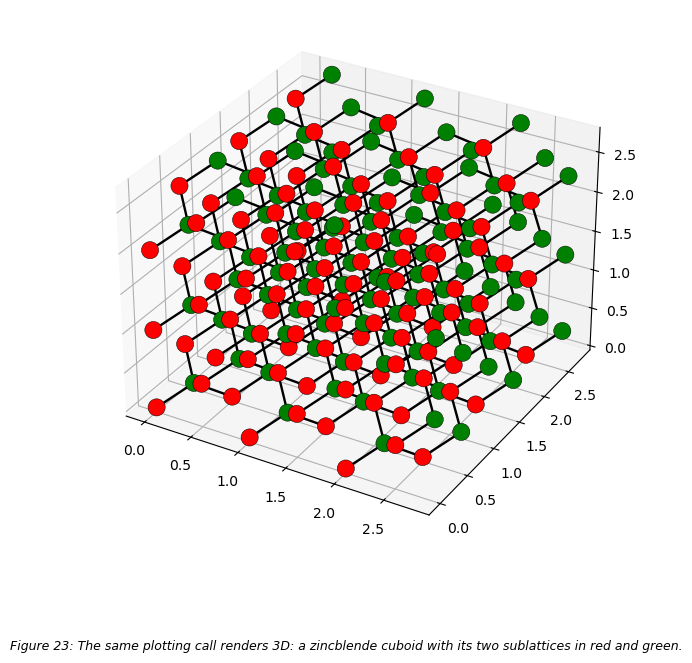

In [6]:
# --- A 3D system plots with the same call ------------------------------------
import kwant

lat3 = kwant.lattice.general([(0, 0.5, 0.5), (0.5, 0, 0.5), (0.5, 0.5, 0)],
                             [(0, 0, 0), (0.25, 0.25, 0.25)], norbs=1)
a3, b3 = lat3.sublattices

def cuboid_shape(pos):
    x, y, z = pos
    return 0 <= x < 3 and 0 <= y < 3 and 0 <= z < 3

cube = kwant.Builder()
cube[lat3.shape(cuboid_shape, (0, 0, 0))] = 0
cube[lat3.neighbors()] = -1

kwant.plot(cube, site_size=0.18, site_lw=0.01, hop_lw=0.05,
           site_color=lambda s: 'r' if s.family == a3 else 'g',
           fig_size=(7, 7), show=False)
show_fig(r'The same plotting call renders 3D: a zincblende cuboid with its two sublattices in red and green.')

In [7]:
# --- ldos and greens_function: two more routes to the same physics ----------
# kwant.ldos sums |psi_n|^2 / (2*pi) over every incoming propagating mode from
# every lead -- verify that directly against kwant.wave_function.
ldos_r = kwant.ldos(fsyst_r, energy=0.4)
wf = kwant.wave_function(fsyst_r, energy=0.4)
manual = sum(np.abs(psi) ** 2 for lead in range(len(fsyst_r.leads)) for psi in wf(lead)) / (2 * np.pi)
print("max |kwant.ldos - manual mode sum| =", np.max(np.abs(ldos_r - manual)))
assert np.allclose(ldos_r, manual, atol=1e-9)

# kwant.greens_function computes transport a completely different way (the
# retarded Green's function between lead interfaces, not mode-matching) and
# still exposes .transmission() -- it must agree with kwant.smatrix.
T_green = kwant.greens_function(fsyst_r, energy=0.4).transmission(1, 0)
T_smatrix = kwant.smatrix(fsyst_r, energy=0.4).transmission(1, 0)
print(f"T (greens_function) = {T_green:.6f}   T (smatrix) = {T_smatrix:.6f}")
assert abs(T_green - T_smatrix) < 1e-9

max |kwant.ldos - manual mode sum| = 5.551115123125783e-16
T (greens_function) = 4.000000   T (smatrix) = 4.000000
